# 6. Supervisor

![Supervisor](docs/router_supervisor.png)
![Supervisor](docs/supervisor.png)

In [1]:
from langchain_openai import AzureChatOpenAI
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.prebuilt import create_react_agent
from langgraph_supervisor import create_supervisor
from datetime import date

Define the model

In [2]:
llm = AzureChatOpenAI(model="gpt-4.1-mini")

Define tools that will be needed by the agent

In [3]:
def book_hotel(destination: str, nights: int, start_date: date) -> str:
    """Book a hotel for a given destination and number of nights"""
    return f"Hotel booked in {destination} for {nights} nights starting from {start_date}. Booking Code: HLT123"


def get_hotels(destination: str, start_date: date) -> list[str]:
    """Get available hotels for a given destination and start date"""
    return ["Holiday Inn", "Marriott", "Hilton"]


def get_flights_available(origin: str, destination: str, date: date) -> list[str]:
    """Get available flights from origin to destination on a specific date"""
    return ["Flight QF32", "Flight QF4", "Flight QF128"]


def book_flight(flight_no: str, date: date) -> str:
    """Book a flight from one location to another on a specific date"""
    return f"Flight {flight_no} booked on {date}, Booking Code: FLY123"


def book_event(event_name: str, date: date) -> str:
    """Book an event ticket for a specific event on a specific date"""
    return f"Ticket booked for {event_name} on {date}. Ticket Code: EVT123"

Create Hotel Booking Agent

In [4]:
tools = [book_hotel, get_hotels]

hotel_booking_agent = create_react_agent(
    model=llm.bind_tools(tools, parallel_tool_calls=False),
    tools=tools,
    prompt="You are a hotel booking agent. You can book hotels and check availability.",
    name="HotelBookingAgent",
)

Create Flight Booking Agent

In [5]:
tools = [book_flight, get_flights_available]

flight_booking_agent = create_react_agent(
    model=llm.bind_tools(tools, parallel_tool_calls=False),
    tools=tools,
    prompt="You are a flight booking agent. You can book flights.",
    name="FlightBookingAgent",
)

Create Event Booking Agent

In [6]:
tools = [book_event]

event_booking_agent = create_react_agent(
    model=llm.bind_tools(tools, parallel_tool_calls=False),
    tools=tools,
    prompt="You are an event booking agent. You can book event tickets.",
    name="EventBookingAgent",
)

Create Supervisor agent

In [7]:
checkpointer = InMemorySaver()
workflow = create_supervisor(
    agents=[hotel_booking_agent, flight_booking_agent, event_booking_agent],
    model=llm,
    prompt=(
        "You are a team supervisor managing a travel agency. "
        "For hotel bookings, use HotelBookingAgent. "
        "For flight bookings, use FlightBookingAgent. "
        "For event bookings, use EventBookingAgent."
    ),
)
app = workflow.compile(checkpointer=checkpointer)

# List of all agents including the supervisor, needed for printing the message in a clear way
agents = ["EventBookingAgent", "FlightBookingAgent", "HotelBookingAgent", "supervisor"]

Printing out the workflow diagram

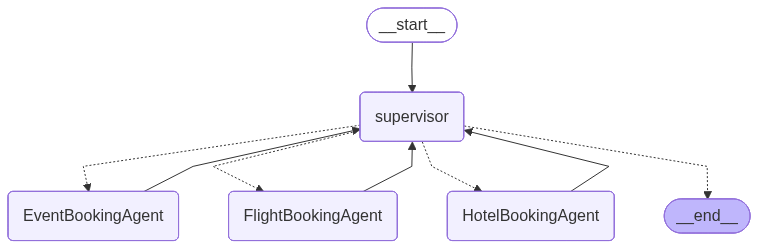

In [8]:
from IPython.display import Image

Image(app.get_graph().draw_mermaid_png())

Executing the workflow

**Example question for workflow**
```
I need your help in a trip to Helsinki. I need a hotel for 14 nights, a flight from London to Helsinki on 2025-11-01, and tickets for the Corteo show of Cirque du Soleil on 2028-11-10.
```

In [9]:
config = {"configurable": {"thread_id": "1", "recursion_limit": 100}}
input_msg = input()
while input_msg.lower() != "exit" or len(input_msg) == 0:
    async for event in app.astream(
        {"messages": [{"role": "user", "content": input_msg}]},
        config,
        stream_mode="updates",
    ):
        for agent in agents:
            for msg in event.get(agent, {}).get("messages", []):
                msg.pretty_print()

    input_msg = input()

================================ Human Message =================================

I need your help in a trip to Helsinki. I need a hotel for 14 nights, a flight from London to Helsinki on 2025-11-01, and tickets for the Corteo show of Cirque du Soleil on 2028-11-10.
================================== Ai Message ==================================
Name: supervisor
Tool Calls:
  transfer_to_flightbookingagent (call_XQcGXKfEGfcN8WWqhqurIA7c)
 Call ID: call_XQcGXKfEGfcN8WWqhqurIA7c
  Args:
================================= Tool Message =================================
Name: transfer_to_flightbookingagent

Successfully transferred to FlightBookingAgent
================================== Ai Message ==================================
Name: FlightBookingAgent

I found three available flights from London to Helsinki on 2025-11-01:
1. Flight QF32
2. Flight QF4
3. Flight QF128

Which flight would you like to book? Also, please note that I can assist with booking flights, but not hotels or show ti

I need your help in a trip to Helsinki. I need a hotel for 14 nights, a flight from London to Helsinki on 2025-11-01, and tickets for the Corteo show of Cirque du Soleil on 2028-11-10.